In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
PATH_DATA = os.getenv('PATH_DATA')

In [2]:
import pandas as pd

pd.options.display.max_columns = 0

def show_df(df):
    display(pd.concat([df.head(2), df.tail(1)]))
    print(df.shape)

In [ ]:
year = 2012
data_path = f"{PATH_DATA}/source/RTE/eCO2mix_RTE_Annuel-Definitif_{year}.xls"

# Le fichier eCO2mix annuel peut être livré en TSV (malgré l'extension .xls)
# ou en vrai format Excel selon l'année/source. On tente TSV puis fallback Excel.
required_cols = {"Date", "Heures", "Consommation"}

def _read_eco2mix(path):
    # Tentative 1: TSV (cas le plus courant sur ce dataset)
    df_try = pd.read_csv(
        path,
        sep="\t",
        skipfooter=2,
        encoding="latin1",
        engine="python",
        decimal=",",
        na_values=["-", "ND", ""],
    )
    df_try.columns = df_try.columns.astype(str).str.strip()

    if required_cols.issubset(set(df_try.columns)):
        return df_try

    # Tentative 2: vrai Excel
    df_try = pd.read_excel(
        path,
        skipfooter=2,
        engine="xlrd",
        na_values=["-", "ND", ""],
    )
    df_try.columns = df_try.columns.astype(str).str.strip()
    return df_try


df = _read_eco2mix(data_path)

# Conversion robuste des colonnes numériques en format FR (virgule décimale)
no_numeric_cols = {"Date", "Heures", "Date - Heure"}
for col in df.columns:
    if col in no_numeric_cols:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        continue

    s = df[col].astype("string").str.strip()
    s = s.replace({"-": pd.NA, "ND": pd.NA, "": pd.NA})
    s_num = pd.to_numeric(
        s.str.replace("\u00A0", "", regex=False)
         .str.replace(" ", "", regex=False)
         .str.replace(",", ".", regex=False),
        errors="coerce",
    )

    non_na = s.notna().sum()
    if non_na > 0 and (s_num.notna().sum() / non_na) >= 0.7:
        df[col] = s_num

missing_required = required_cols.difference(df.columns)
if missing_required:
    raise ValueError(
        f"Colonnes requises introuvables: {missing_required}. Colonnes dispo: {list(df.columns)[:20]}"
    )

show_df(df)


,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,Taux de Co2,Ech. comm. Angleterre,Ech. comm. Espagne,Ech. comm. Italie,Ech. comm. Suisse,Ech. comm. Allemagne-Belgique,Fioul - TAC,Fioul - Cogén.,Fioul - Autres,Gaz - TAC,Gaz - Cogén.,Gaz - CCG,Gaz - Autres,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz
France,Données définitives,2012-01-01,00:00,58315.0,58200,58200,492.0,25.0,3816.0,52697.0,3588.0,0.0,7922.0,-1139.0,719.0,-9806.0,33.0,-1750.0,-1200.0,-862.0,-2625.0,-2940.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
France,Données définitives,2012-01-01,00:15,NaN,57700,57550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
France,Données définitives,2012-12-31,23:45,NaN,60400,60500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(35136, 36)


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 35136 entries, France to France
Data columns (total 36 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Périmètre                             35136 non-null  str    
 1   Nature                                35136 non-null  str    
 2   Date                                  35136 non-null  str    
 3   Heures                                17568 non-null  float64
 4   Consommation                          35136 non-null  int64  
 5   Prévision J-1                         35136 non-null  int64  
 6   Prévision J                           17568 non-null  float64
 7   Fioul                                 17568 non-null  float64
 8   Charbon                               17568 non-null  float64
 9   Gaz                                   17568 non-null  float64
 10  Nucléaire                             17568 non-null  float64
 11  Eolien                   

---
## 1. Aperçu des données brutes

Examen du schéma, des types de colonnes et des valeurs manquantes.


In [5]:
# Types, cardinalité et valeurs manquantes pour chaque colonne
print(f"Shape : {df.shape}")
print(f"\nColonnes disponibles ({len(df.columns)}) :")
for col in df.columns:
    n_miss = df[col].isnull().sum()
    pct = n_miss / len(df) * 100
    flag = f"  ⚠  {n_miss:,} manquants ({pct:.1f}%)" if n_miss > 0 else ""
    print(f"  {col!r:50s} {str(df[col].dtype):12s}{flag}")


Shape : (35136, 36)

Colonnes disponibles (36) :
  'Périmètre'                                        str         
  'Nature'                                           str         
  'Date'                                             str         
  'Heures'                                           float64       ⚠  17,568 manquants (50.0%)
  'Consommation'                                     int64       
  'Prévision J-1'                                    int64       
  'Prévision J'                                      float64       ⚠  17,568 manquants (50.0%)
  'Fioul'                                            float64       ⚠  17,568 manquants (50.0%)
  'Charbon'                                          float64       ⚠  17,568 manquants (50.0%)
  'Gaz'                                              float64       ⚠  17,568 manquants (50.0%)
  'Nucléaire'                                        float64       ⚠  17,568 manquants (50.0%)
  'Eolien'                                         

## 2. Parsing des dates et construction de l'index temporel

Les données sont à pas de **30 minutes**. On construit un `DatetimeIndex` et on vérifie la couverture.


In [30]:
# Construction robuste du DatetimeIndex (gère les variantes de colonnes eCO2mix)

def _is_hour_string(series):
    s = series.astype("string").str.strip()
    return s.str.match(r"^\d{2}:\d{2}$", na=False).mean()

def _is_date_string(series):
    s = series.astype("string").str.strip()
    p_fr = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
    p_iso = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    return p_fr.combine_first(p_iso).notna().mean()

candidate_cols = [c for c in ["Date", "Heures", "Nature", "Date - Heure"] if c in df.columns]
if len(candidate_cols) < 2:
    raise ValueError(f"Colonnes insuffisantes pour construire datetime. Disponibles: {list(df.columns)}")

hour_col = max(candidate_cols, key=lambda c: _is_hour_string(df[c]))
date_col = max(candidate_cols, key=lambda c: _is_date_string(df[c]) if c != hour_col else -1)

date_part = df[date_col].astype("string").str.strip()
hour_part = df[hour_col].astype("string").str.strip()
combined = date_part + " " + hour_part

dt_fr = pd.to_datetime(combined, format="%d/%m/%Y %H:%M", errors="coerce")
dt_iso = pd.to_datetime(combined, format="%Y-%m-%d %H:%M", errors="coerce")
df["datetime"] = dt_fr.combine_first(dt_iso)

n_invalid = df["datetime"].isnull().sum()
print(f"Colonnes retenues pour datetime : date='{date_col}', heure='{hour_col}'")
print(f"Dates invalides après parsing : {n_invalid}")

df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

print(f"\nCouverture temporelle :")
print(f"  Début    : {df.index.min()}")
print(f"  Fin      : {df.index.max()}")
print(f"  Lignes   : {len(df):,}")

# Vérification des trous dans la série selon fréquence observée
if len(df.index) > 2:
    step = df.index.to_series().diff().dropna().median()
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq=step)
    gaps = full_idx.difference(df.index)
    print(f"  Pas observé médian : {step}")
    print(f"  Pas de temps manquants : {len(gaps)}")
else:
    print("  Série trop courte pour estimer la fréquence.")

dupes = df.index.duplicated().sum()
print(f"Doublons d'index        : {dupes}")


Colonnes retenues pour datetime : date='Nature', heure='Date'
Dates invalides après parsing : 0

Couverture temporelle :
  Début    : 2012-01-01 00:00:00
  Fin      : 2012-12-31 23:45:00
  Lignes   : 35,136
  Pas observé médian : 0 days 00:15:00
  Pas de temps manquants : 0
Doublons d'index        : 0


## 3. Variable cible — Consommation journalière

Agrégation des mesures 30 min → **énergie journalière en MWh** (MW × 0,5 h).  
On filtre les jours incomplets (transitions DST : 46 ou 50 mesures sont normales, on accepte ≥ 44).


In [22]:
CONSO_COL = "Consommation"
assert CONSO_COL in df.columns, f"Colonne '{CONSO_COL}' introuvable. Colonnes dispo : {list(df.columns)}"

# Pas temporel (heures) déduit de la série ; fallback 0.5h
step_hours = 0.5
if len(df.index) > 2:
    step = df.index.to_series().diff().dropna().median()
    step_hours = step.total_seconds() / 3600

if step_hours <= 0 or pd.isna(step_hours):
    step_hours = 0.5

expected_per_day = max(1, int(round(24 / step_hours)))
min_points_per_day = int(round(expected_per_day * 0.9))

# Agrégation journalière : MWh = Σ(MW × pas_en_heures)
daily = (
    df[CONSO_COL]
    .dropna()
    .resample("1D")
    .agg(conso_MWh=lambda x: (x * step_hours).sum(), n_mesures="count")
)

# Garder uniquement les jours suffisamment complets
daily = daily.query("n_mesures >= @min_points_per_day").copy()

print(f"Pas détecté : {step_hours:.2f} h")
print(f"Mesures/j attendues : {expected_per_day} (seuil min: {min_points_per_day})")
print(f"Jours disponibles : {len(daily)}")
print(f"Jours exclus (données insuffisantes) : {df.index.normalize().nunique() - len(daily)}")

if daily.empty:
    raise ValueError(
        "La série journalière est vide. Vérifier le parsing de 'Date/Heures' et la conversion numérique de 'Consommation'."
    )

display(daily["conso_MWh"].describe().rename("conso_MWh").to_frame().T)


Pas détecté : 0.25 h
Mesures/j attendues : 96 (seuil min: 86)
Jours disponibles : 366
Jours exclus (données insuffisantes) : 0


,count,mean,std,min,25%,50%,75%,max
conso_MWh,366.0,1.323699e+06,288283.416842,886237.5,1130762.5,1232468.75,1516490.625,2236337.5


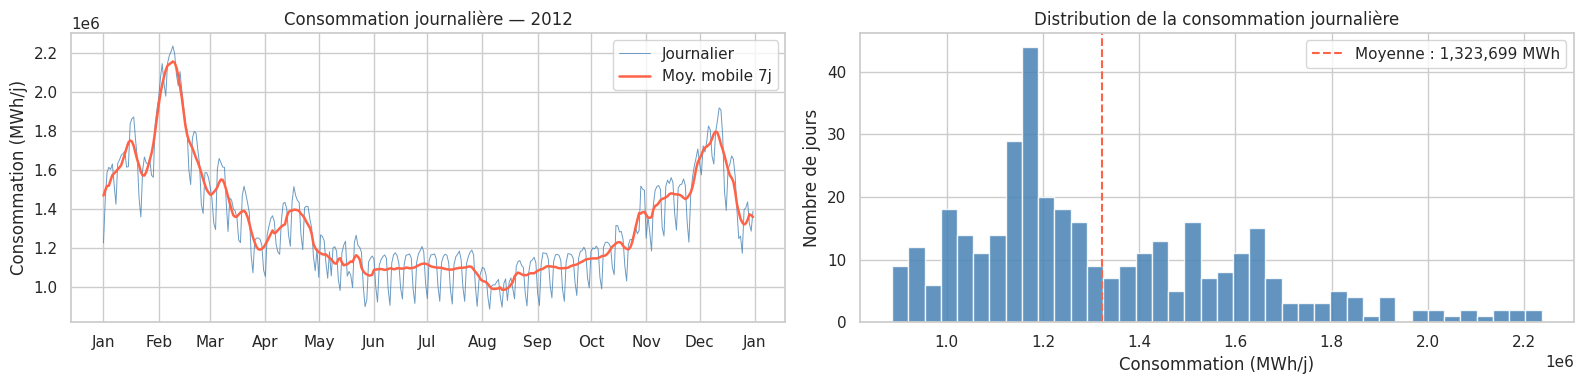

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Série temporelle ---
ax = axes[0]
ax.plot(daily.index, daily["conso_MWh"], linewidth=0.7, color="steelblue", alpha=0.8, label="Journalier")
rolling = daily["conso_MWh"].rolling(7, center=True, min_periods=3).mean()
ax.plot(daily.index, rolling, color="tomato", linewidth=1.8, label="Moy. mobile 7j")
ax.set_title(f"Consommation journalière — {year}")
ax.set_ylabel("Consommation (MWh/j)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()

# --- Distribution ---
ax = axes[1]
ax.hist(daily["conso_MWh"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(
    daily["conso_MWh"].mean(), color="tomato", linestyle="--",
    label=f"Moyenne : {daily['conso_MWh'].mean():,.0f} MWh"
)
ax.set_title("Distribution de la consommation journalière")
ax.set_xlabel("Consommation (MWh/j)")
ax.set_ylabel("Nombre de jours")
ax.legend()

plt.tight_layout()
plt.show()


## 4. Feature engineering — variables temporelles

Création des features dérivées de la date : saisonnalité, pattern hebdomadaire, jours fériés, et **features lag** (autocorrélation).


In [31]:
daily["mois"]         = daily.index.month
daily["jour_semaine"] = daily.index.dayofweek          # 0 = Lundi … 6 = Dimanche
daily["semaine_iso"]  = daily.index.isocalendar().week.astype(int)
daily["est_weekend"]  = (daily["jour_semaine"] >= 5).astype(int)

SAISONS = {
    12: "Hiver",  1: "Hiver",  2: "Hiver",
     3: "Printemps", 4: "Printemps", 5: "Printemps",
     6: "Été",    7: "Été",    8: "Été",
     9: "Automne",10: "Automne",11: "Automne",
}
daily["saison"] = daily["mois"].map(SAISONS)

# Jours fériés fixes — enrichir avec lib 'holidays' pour Pâques/Ascension/Pentecôte
FERIES_FIXES = {
    f"{year}-01-01", f"{year}-05-01", f"{year}-05-08",
    f"{year}-07-14", f"{year}-08-15", f"{year}-11-01",
    f"{year}-11-11", f"{year}-12-25",
}
daily["est_ferie"] = daily.index.strftime("%Y-%m-%d").isin(FERIES_FIXES).astype(int)

# Features lag (autocorrélation)
daily["conso_lag_1j"]     = daily["conso_MWh"].shift(1)
daily["conso_lag_7j"]     = daily["conso_MWh"].shift(7)
daily["conso_rolling_7j"] = daily["conso_MWh"].rolling(7, min_periods=1).mean().shift(1)

print(f"Features créées : {list(daily.columns)}")
daily.dropna().head(10)


Features créées : ['conso_MWh', 'n_mesures', 'mois', 'jour_semaine', 'semaine_iso', 'est_weekend', 'saison', 'est_ferie', 'conso_lag_1j', 'conso_lag_7j', 'conso_rolling_7j']


,conso_MWh,n_mesures,mois,jour_semaine,semaine_iso,est_weekend,saison,est_ferie,conso_lag_1j,conso_lag_7j,conso_rolling_7j
datetime,,,,,,,,,,,
2012-01-08,1424237.5,96,1,6,1,1,Hiver,0,1524137.5,1225462.5,1.519055e+06
2012-01-09,1633125.0,96,1,0,2,0,Hiver,0,1424237.5,1449112.5,1.547452e+06
2012-01-10,1652212.5,96,1,1,2,0,Hiver,0,1633125.0,1587387.5,1.573739e+06
2012-01-11,1676000.0,96,1,2,2,0,Hiver,0,1652212.5,1613862.5,1.583000e+06
2012-01-12,1684175.0,96,1,3,2,0,Hiver,0,1676000.0,1602537.5,1.591877e+06
2012-01-13,1696262.5,96,1,4,2,0,Hiver,0,1684175.0,1630887.5,1.603539e+06
2012-01-14,1614587.5,96,1,5,2,1,Hiver,0,1696262.5,1524137.5,1.612879e+06
2012-01-15,1617512.5,96,1,6,2,1,Hiver,0,1614587.5,1424237.5,1.625800e+06
2012-01-16,1837087.5,96,1,0,3,0,Hiver,0,1617512.5,1633125.0,1.653411e+06


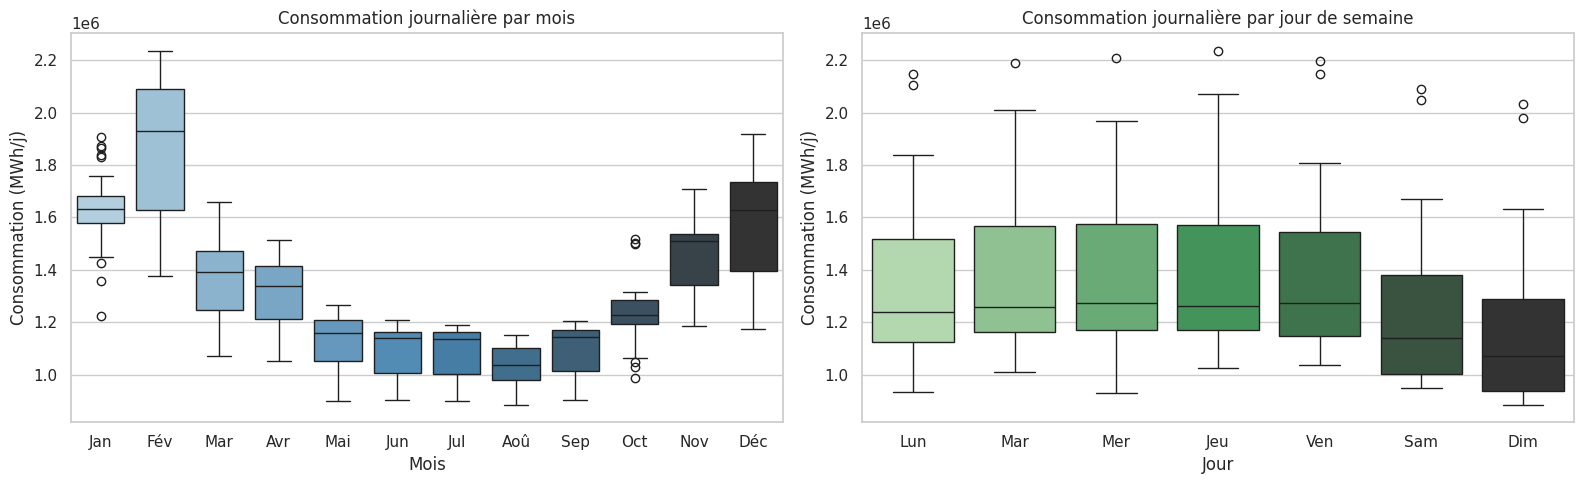

Moyenne semaine : 1,374,814 MWh
Moyenne weekend : 1,196,642 MWh
Moyenne fériés  : 1,116,158 MWh


In [32]:
MOIS_LABELS  = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
JOURS_LABELS = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=daily, x="mois", y="conso_MWh", ax=axes[0],
            hue="mois", palette="Blues_d", legend=False)
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(MOIS_LABELS)
axes[0].set_title("Consommation journalière par mois")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Consommation (MWh/j)")

sns.boxplot(data=daily, x="jour_semaine", y="conso_MWh", ax=axes[1],
            hue="jour_semaine", palette="Greens_d", legend=False)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(JOURS_LABELS)
axes[1].set_title("Consommation journalière par jour de semaine")
axes[1].set_xlabel("Jour")
axes[1].set_ylabel("Consommation (MWh/j)")

plt.tight_layout()
plt.show()

print(f"Moyenne semaine : {daily[daily['est_weekend']==0]['conso_MWh'].mean():,.0f} MWh")
print(f"Moyenne weekend : {daily[daily['est_weekend']==1]['conso_MWh'].mean():,.0f} MWh")
print(f"Moyenne fériés  : {daily[daily['est_ferie']==1]['conso_MWh'].mean():,.0f} MWh")


## 5. Sources de production — analyse et corrélations

Visualisation du mix énergétique et corrélations des sources avec la consommation.  
> Note : *Pompage* et *Échanges physiques* sont exclus car ils peuvent être négatifs.


Colonnes de production disponibles : ['Nucléaire', 'Hydraulique', 'Gaz', 'Eolien', 'Solaire', 'Fioul', 'Charbon', 'Bioénergies']


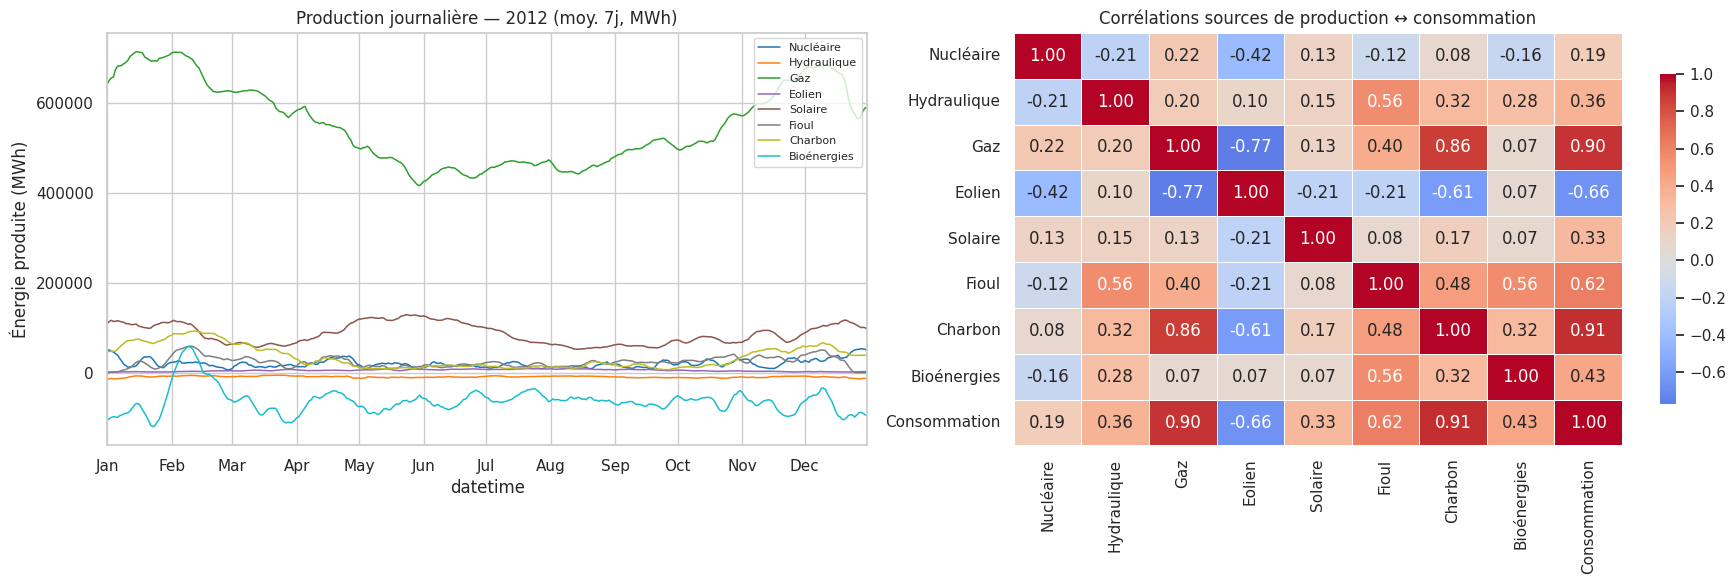

In [33]:
PROD_COLS = ["Nucléaire", "Hydraulique", "Gaz", "Eolien", "Solaire",
             "Fioul", "Charbon", "Bioénergies"]
prod_cols_ok = [c for c in PROD_COLS if c in df.columns]
print(f"Colonnes de production disponibles : {prod_cols_ok}")

if not prod_cols_ok:
    print("Aucune colonne de production trouvée dans ce fichier.")
else:
    # Agrégation journalière (MWh), alignée sur les jours complets
    daily_prod = (df[prod_cols_ok].resample("1D").sum() * step_hours).reindex(daily.index)

    # Corrélation avec la consommation
    corr_matrix = daily_prod.assign(Consommation=daily["conso_MWh"]).corr()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Certaines colonnes peuvent contenir des valeurs mixtes +/- (ex: bioénergies).
    # On trace en lignes pour éviter l'erreur de stacking.
    daily_prod.rolling(7, center=True, min_periods=3).mean().plot(
        ax=axes[0], linewidth=1.1, colormap="tab10"
    )
    axes[0].set_title(f"Production journalière — {year} (moy. 7j, MWh)")
    axes[0].set_ylabel("Énergie produite (MWh)")
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    axes[0].xaxis.set_major_locator(mdates.MonthLocator())
    axes[0].legend(loc="upper right", fontsize=8)

    # Heatmap des corrélations
    sns.heatmap(
        corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        ax=axes[1], linewidths=0.5, cbar_kws={"shrink": 0.8}
    )
    axes[1].set_title("Corrélations sources de production ↔ consommation")

    plt.tight_layout()
    plt.show()


## 6. Qualité des données — valeurs aberrantes

Détection des outliers sur la consommation journalière via la méthode IQR.


Bornes IQR : [552,170 — 2,095,083] MWh
Outliers   : 7 jour(s) (1.9%)


,conso_MWh,mois,saison,est_weekend,est_ferie
datetime,,,,,
2012-02-03,2145587.5,2,Hiver,0,0
2012-02-06,2147100.0,2,Hiver,0,0
2012-02-07,2187087.5,2,Hiver,0,0
2012-02-08,2207687.5,2,Hiver,0,0
2012-02-09,2236337.5,2,Hiver,0,0
2012-02-10,2197687.5,2,Hiver,0,0
2012-02-13,2105150.0,2,Hiver,0,0


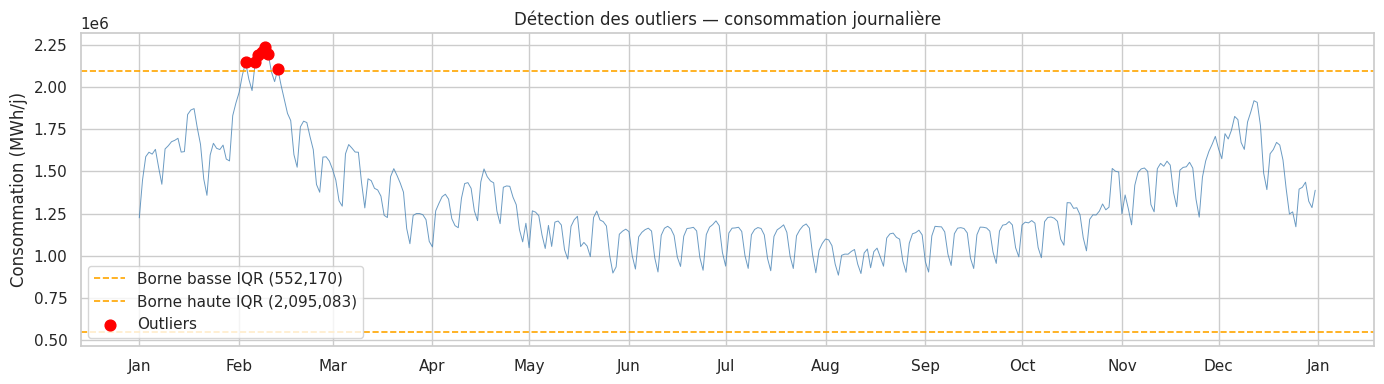

In [34]:
if daily.empty:
    print("Aucune donnée journalière disponible: corriger les étapes de chargement/parsing amont.")
else:
    Q1, Q3 = daily["conso_MWh"].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    outliers = daily[(daily["conso_MWh"] < lower) | (daily["conso_MWh"] > upper)]

    print(f"Bornes IQR : [{lower:,.0f} — {upper:,.0f}] MWh")
    print(f"Outliers   : {len(outliers)} jour(s) ({len(outliers)/len(daily)*100:.1f}%)")

    if len(outliers):
        cols_meta = ["conso_MWh", "mois", "saison", "est_weekend", "est_ferie"]
        cols_meta = [c for c in cols_meta if c in outliers.columns]
        display(outliers[cols_meta])

    # Visualisation
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(daily.index, daily["conso_MWh"], color="steelblue", linewidth=0.7, alpha=0.8)
    ax.axhline(lower, color="orange", linestyle="--", linewidth=1.2, label=f"Borne basse IQR ({lower:,.0f})")
    ax.axhline(upper, color="orange", linestyle="--", linewidth=1.2, label=f"Borne haute IQR ({upper:,.0f})")
    if len(outliers):
        ax.scatter(outliers.index, outliers["conso_MWh"], color="red", zorder=5, s=60, label="Outliers")
    ax.set_title("Détection des outliers — consommation journalière")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.legend()
    plt.tight_layout()
    plt.show()


## 7. Intégration des données météo (à venir)

La consommation électrique est fortement corrélée à la température (chauffage en hiver, climatisation en été).

**Source prévue :** [Open-Meteo Historical API](https://open-meteo.com/en/docs/historical-weather-api) — API gratuite, aucune clé requise.

| Feature | Description |
|---|---|
| `temp_mean_C` | Température moyenne journalière (°C) |
| `temp_min_C` / `temp_max_C` | Min/max journaliers |
| `HDD` | Heating Degree Days = max(0, 18 − temp_mean) |
| `CDD` | Cooling Degree Days = max(0, temp_mean − 18) |

> Coordonnées de référence : Paris (lat=48.85, lon=2.35) ou centroïde France (lat=46.23, lon=2.21).


In [35]:
# Placeholder Open-Meteo — décommenter après : pip install openmeteo-requests requests-cache retry-requests

# import openmeteo_requests, requests_cache
# from retry_requests import retry
#
# session = retry(requests_cache.CachedSession('.cache', expire_after=-1), retries=5)
# client  = openmeteo_requests.Client(session=session)
#
# resp = client.weather_api(
#     "https://archive-api.open-meteo.com/v1/archive",
#     params={
#         "latitude": 46.23, "longitude": 2.21,
#         "start_date": f"{year}-01-01", "end_date": f"{year}-12-31",
#         "daily": ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"],
#         "timezone": "Europe/Paris",
#     }
# )[0].Daily()
#
# meteo = pd.DataFrame({
#     "date":        pd.date_range(f"{year}-01-01", periods=resp.VariablesLength(), freq="1D"),
#     "temp_max_C":  resp.Variables(0).ValuesAsNumpy(),
#     "temp_min_C":  resp.Variables(1).ValuesAsNumpy(),
#     "temp_mean_C": resp.Variables(2).ValuesAsNumpy(),
# }).set_index("date")
# meteo["HDD"] = (18 - meteo["temp_mean_C"]).clip(lower=0)
# meteo["CDD"] = (meteo["temp_mean_C"] - 18).clip(lower=0)
# daily = daily.join(meteo)

print("TODO : décommenter le bloc ci-dessus après installation de openmeteo-requests")
print(f"       Période cible : {year}-01-01 → {year}-12-31")


TODO : décommenter le bloc ci-dessus après installation de openmeteo-requests
       Période cible : 2012-01-01 → 2012-12-31


## 8. Synthèse — Plan de feature engineering pour les modèles ML

Récapitulatif des features retenues, de l'encodage et des étapes suivantes.


In [36]:
feature_plan = {
    "TARGET": [
        "conso_MWh — consommation électrique journalière totale (MWh)",
    ],
    "Temporelles": [
        "mois          → saisonnalité annuelle (1–12)",
        "jour_semaine  → pattern hebdomadaire (0=Lun … 6=Dim)",
        "semaine_iso   → numéro de semaine ISO",
        "est_weekend   → binaire (Samedi ou Dimanche)",
        "est_ferie     → binaire (jour férié français)",
        "saison        → Hiver / Printemps / Été / Automne",
    ],
    "Météo (à intégrer — Open-Meteo)": [
        "temp_mean_C   → température moyenne journalière",
        "HDD           → Heating Degree Days  (fortement corrélé au chauffage)",
        "CDD           → Cooling Degree Days  (climatisation)",
    ],
    "Lag / Autocorrélation": [
        "conso_lag_1j     → consommation J−1",
        "conso_lag_7j     → consommation J−7 (même jour de la semaine précédente)",
        "conso_rolling_7j → moyenne mobile 7 jours décalée d'un jour",
    ],
    "Encodage pour les modèles": [
        "saison, mois  → one-hot encoding (ou ordinal pour arbres)",
        "Continus      → StandardScaler pour KNN et réseaux de neurones",
        "Arbres / RF   → pas de normalisation nécessaire",
    ],
}

for section, items in feature_plan.items():
    print(f"\n{'─'*60}")
    print(f"  {section.upper()}")
    print(f"{'─'*60}")
    for item in items:
        print(f"    • {item}")

n_feat = sum(len(v) for k, v in feature_plan.items() if "TARGET" not in k and "Météo" not in k)
n_feat_meteo = n_feat + 3

print(f"\n{'═'*60}")
print(f"  Dataset actuel  : {len(daily.dropna())} jours × {n_feat} features (sans météo)")
print(f"  Après météo     : {len(daily.dropna())} jours × {n_feat_meteo} features")
print(f"  Split prévu     : 2012–2022 train  |  2023–2024 test")
print(f"  Modèles cibles  : Arbre décision, Forêt aléatoire, KNN, Réseau de neurones")
print(f"  Métriques       : R² Scoring, RMSE, MAPE, temps d'entraînement")
print(f"{'═'*60}")



────────────────────────────────────────────────────────────
  TARGET
────────────────────────────────────────────────────────────
    • conso_MWh — consommation électrique journalière totale (MWh)

────────────────────────────────────────────────────────────
  TEMPORELLES
────────────────────────────────────────────────────────────
    • mois          → saisonnalité annuelle (1–12)
    • jour_semaine  → pattern hebdomadaire (0=Lun … 6=Dim)
    • semaine_iso   → numéro de semaine ISO
    • est_weekend   → binaire (Samedi ou Dimanche)
    • est_ferie     → binaire (jour férié français)
    • saison        → Hiver / Printemps / Été / Automne

────────────────────────────────────────────────────────────
  MÉTÉO (À INTÉGRER — OPEN-METEO)
────────────────────────────────────────────────────────────
    • temp_mean_C   → température moyenne journalière
    • HDD           → Heating Degree Days  (fortement corrélé au chauffage)
    • CDD           → Cooling Degree Days  (climatisation)

────